In [1]:
# 1,線形回帰
# 2,ダミー変数を用いた回帰
# 3,ロジスティック回帰による分類
# 4,多項式回帰
# 5,過剰適合
# 6,リッジ回帰
# 7,カーネルとSVM (Support Vector Machine)
# 8,仮説の評価
# 9,ニューラルネット
# 10,単純Bayes
# 11,決定木
# 12,アンサンブル法
# 13,クラスタリング
# 14,次元削減
# 15,特徴量の重要度

In [2]:
!pip install -U yellowbrick
import yellowbrick
yellowbrick.__version__

# Warningについて
# Yellowbrickとscikit-learnのバージョン違いで注意 (Warning) が出ることがある． また，最適化が収束しないと注意 (Warning) が出ることがある．

# 鬱陶しい場合には，以下のコードを実行しておく．

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
simplefilter(action='ignore', category=FutureWarning)

#線形回帰

In [3]:
# 広告による売り上げの予測
# 広告のデータ http://logopt.com/data/Advertising.csv を用いる．
# テレビ(TV)，ラジオ(Radio)，新聞(Newspaper)への広告から売り上げ(Sales)を予測する．

import pandas as pd #まずはpandasモジュールを準備する．

In [4]:
df = pd.read_csv('http://logopt.com/data/Advertising.csv', index_col =0) #0行目をインデックスにする．
df.tail()

,TV,Radio,Newspaper,Sales
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,8.6,8.7,13.4


In [5]:
# 独立変数（特徴ベクトル）XX は TV, Radio, Newspaperの列，従属変数（ターゲット） yy は Salesの列

y = df['Sales']
X = df[['TV', 'Radio', 'Newspaper']]# df.drop("Sales",axis=1) でも同じ
X.head()

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4


#scikit-learnの基本手順

In [6]:
# 手順１：クラスをインポートして，インスタンスを生成する．
# 手順２：fitメソッドを用いて，データから訓練する．
# 手順３：predictメソッドを用いて予測を行う．

In [7]:
from sklearn.linear_model import LinearRegression #線形回帰クラス LinearRegression のインポート
reg = LinearRegression() # 線形回帰クラスのインスタンス reg 生成
reg.fit(X, y)           # fitによる訓練
yhat = reg.predict(X)   # predictによる予測

In [8]:
print("y-切片= ",reg.intercept_)
print("係数 = ",reg.coef_)

y-切片=  2.938889369459412
係数 =  [ 0.04576465  0.18853002 -0.00103749]


In [9]:
SSE = ((yhat-y)**2).sum()      # Sum of Square Error
SST = ((y.mean()-y)**2).sum()  # Total Sum of Square
print("R2 =", 1-SSE/SST)       # 決定係数 R^2

R2 = 0.8972106381789522


In [10]:
print(reg.score(X,y)) #決定係数の別計算

0.8972106381789522


#可視化（回帰）

In [11]:
# Yellowbrickパッケージを用いる．
# https://www.scikit-yb.org/en/latest/index.html
# インストール
!pip install -U yellowbrick

#可視化の基本手順

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


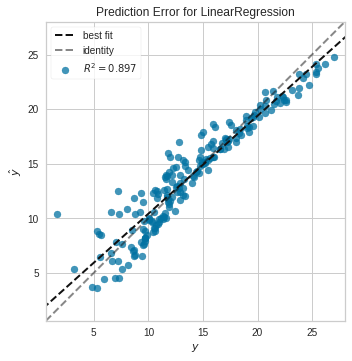

In [12]:
# 手順１：クラスをインポートして，可視化インスタンスを生成する．
# 手順２：fitメソッドで，データを用いて訓練する．
# 手順３：scoreメソッドを用いて評価尺度を計算する．
# 手順４：showメソッドを用いて図を表示する．

# 回帰に対しては，以下の2種類がある．
# 予測誤差 (PredictionError)
# 残差プロット (ResidualPlot)

from yellowbrick.regressor import PredictionError

visualizer = PredictionError(reg)

visualizer.fit(X, y)  
visualizer.score(X, y)  
visualizer.show();

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


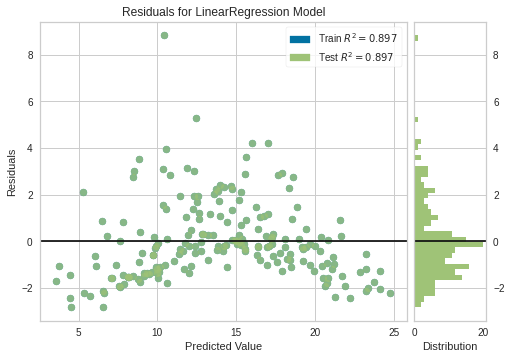

In [13]:
from yellowbrick.regressor import ResidualsPlot

visualizer = ResidualsPlot(reg)

visualizer.fit(X, y)  
visualizer.score(X, y)  
visualizer.show();

In [14]:
# 問題 (SAT,GPA)
# http://logopt.com/data/SATGPA.csv データを用いて，2種類のSATの成績からGPAを予測せよ． さらに結果の可視化を行え．


In [15]:
# 問題（住宅価格）
# http://logopt.com/data/Boston.csv のBostonの住宅データを用いて回帰分析を行え． 
# さらに結果の可視化を行え． medvが住宅の価格で，他のデータ（犯罪率や人口など）から予測する．

In [16]:
# 問題（車の燃費）
# http://logopt.com/data/Auto.csv の車の燃費のデータを用いて回帰分析を行え． さらに結果の可視化を行え．

# データの詳細については，

# https://vincentarelbundock.github.io/Rdatasets/doc/ISLR/Auto.html

# を参照せよ．

# 最初の列が燃費（mpg: Mile Per Gallon)であり，これを他の列の情報を用いて予測する．最後の列は車名なので無視して良い．

car = pd.read_csv("http://logopt.com/data/Auto.csv", index_col=0)
car.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [17]:
# 問題（コンクリートの強度）
# 以下のコンクリートの強度の例題に対して，strength列の強度を他の列の情報から，線形回帰を用いて推定せよ． さらに結果の可視化を行え．

concrete = pd.read_csv("http://logopt.com/data/concrete.csv")
concrete.head()

,cement,slag,ash,water,splast,coarse,fine,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [18]:
# 問題（シェアバイク）
# 以下のシェアバイクのデータに対して，riders列が利用者数を，線形回帰を用いて推定せよ．ただし，date列とcasual列は除いてから回帰を行え． さらに結果の可視化を行え．

# また，なぜcasual列を含めて推定をしないのか考察せよ．

bikeshare = pd.read_csv("http://logopt.com/data/bikeshare.csv")
bikeshare.head()

,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,feelslike,humidity,windspeed,casual,registered,riders
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#ダミー変数を用いた回帰

In [19]:
# ダイヤモンドの価格の予測（ダミー変数）
# http://logopt.com/data/Diamond.csv からダイアモンドの価格データを読み込み，線形回帰による予測を行う．

# 列は ["carat","colour","clarity","certification","price"] であり，他の情報から価格(price)の予測を行え．

# カラット(carat)以外の列は情報が文字列として保管されている．
# これはカテゴリー変数とよばれ，sciki-learnで扱うには，数値に変換する必要がある．

# pandasのget_dummies関数で数値情報（ダミー変数）に変換してから，線形回帰を行う．
# たとえば，色を表すcolour列はD,E,F,G,H,Iの文字列が入っている．これを各値が入っているとき1，それ以外のとき0の数値に変換したものがダミー変数になる．

# 色はいずれかの値をとるので，ダミー変数は独立でない（1つが1になると，他のすべては0になる）．
# 最初のダミー変数を除くには，get_dummies関数の引数のdrop_firstをTrueに設定すれば良い．

import pandas as pd
diamond = pd.read_csv('http://logopt.com/data/Diamond.csv', index_col=0)
diamond.head()

,carat,colour,clarity,certification,price
1,0.30,D,VS2,GIA,1302
2,0.30,E,VS1,GIA,1510
3,0.30,G,VVS1,GIA,1510
4,0.30,G,VS1,GIA,1260
5,0.31,D,VS1,GIA,1641


In [20]:
diamond = pd.get_dummies(diamond, drop_first=True) #ダミー変数の最初のものを除く
#diamond = pd.get_dummies(diamond) # 除かなくても結果は同じ
diamond.head()

,carat,price,colour_E,colour_F,colour_G,colour_H,colour_I,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,certification_HRD,certification_IGI
1,0.30,1302,0,0,0,0,0,0,1,0,0,0,0
2,0.30,1510,1,0,0,0,0,1,0,0,0,0,0
3,0.30,1510,0,0,1,0,0,0,0,1,0,0,0
4,0.30,1260,0,0,1,0,0,1,0,0,0,0,0
5,0.31,1641,0,0,0,0,0,1,0,0,0,0,0


In [21]:
y = diamond.price                # 従属変数(price)の抽出
X = diamond.drop('price',axis=1) # 独立変数（特徴ベクトル）をpriceの列を除くことによって生成
X.head()

,carat,colour_E,colour_F,colour_G,colour_H,colour_I,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,certification_HRD,certification_IGI
1,0.30,0,0,0,0,0,0,1,0,0,0,0
2,0.30,1,0,0,0,0,1,0,0,0,0,0
3,0.30,0,0,1,0,0,0,0,1,0,0,0
4,0.30,0,0,1,0,0,1,0,0,0,0,0
5,0.31,0,0,0,0,0,1,0,0,0,0,0


In [22]:
from sklearn.linear_model import LinearRegression #線形回帰クラスのインポート
reg = LinearRegression() # 線形回帰クラスのインスタンス生成
reg.fit(X, y)           # 訓練
yhat = reg.predict(X)   # 予測

In [23]:
print("y-切片= ",reg.intercept_)
print("係数 = ",reg.coef_)
print("決定変数= ",reg.score(X,y)) #決定係数の別計算

y-切片=  169.17604383492744
係数 =  [12766.39597047 -1439.0853427  -1841.69054716 -2176.67218633
 -2747.14998002 -3313.1023993  -1474.56614749 -1792.01092358
  -689.29043537 -1191.16426364    15.22672874   141.2624469 ]
決定変数=  0.9581280577870392


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


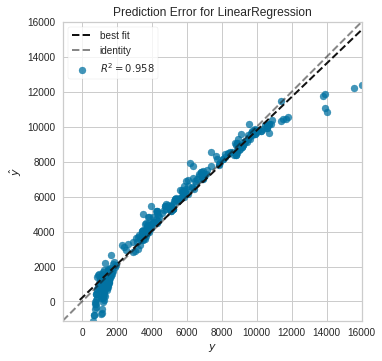

In [24]:
visualizer = PredictionError(reg)

visualizer.fit(X, y)  
visualizer.score(X, y)  
visualizer.show();

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


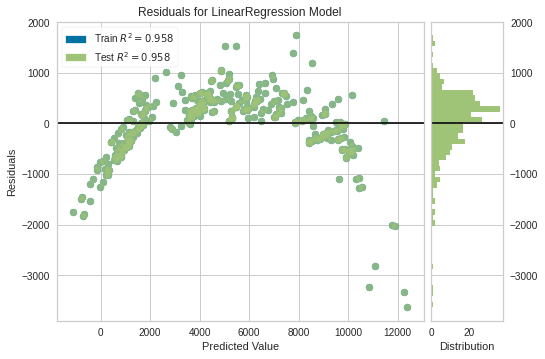

In [25]:
visualizer = ResidualsPlot(reg)

visualizer.fit(X, y)  
visualizer.score(X, y)  
visualizer.show();

In [26]:
# 問題（車の価格）
# http://logopt.com/data/carprice.csv から車の価格データを読み込み，線形回帰による予測を行え． また，結果を可視化せよ．

# データの詳細は https://vincentarelbundock.github.io/Rdatasets/doc/DAAG/carprice.html にある．

# 車種(Type)，100マイル走る際のガロン数（gpm100），都市部での1ガロンあたりの走行距離（MPGcity），高速道路での１ガロン当たりの走行距離（MPGhighway）から，価格(Price)を予測せよ．

carprice = pd.read_csv("http://logopt.com/data/carprice.csv", index_col=0)
carprice.head()

,Type,MinPrice,Price,MaxPrice,RangePrice,RoughRange,gpm100,MPGcity,MPGhighway
6,Midsize,14.2,15.7,17.3,3.1,3.09,3.8,22,31
7,Large,19.9,20.8,21.7,1.8,1.79,4.2,19,28
8,Large,22.6,23.7,24.9,2.3,2.31,4.9,16,25
9,Midsize,26.3,26.3,26.3,0.0,-0.01,4.3,19,27
10,Large,33.0,34.7,36.3,3.3,3.30,4.9,16,25


In [27]:
# 問題（チップ）
# チップ（tips）データに対して線形回帰を用いてもらえるチップの額 (tip) を予測せよ． また，結果を可視化せよ．

import seaborn as sns
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#ロジスティック回帰による分類

In [28]:
# スパムの判定
# メールがスパム（spam；迷惑メイル）か否かを判定する例題を用いる．

# https://archive.ics.uci.edu/ml/datasets/spambase

# 様々な数値情報から，is_spam列が 11 （スパムでない）か， 00 （スパム）かを判定する．

import pandas as pd
spam = pd.read_csv("http://logopt.com/data/spam.csv")
spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1


In [29]:
# is_spam列が従属変数（ターゲット）yy になり，それ以外の列が独立変数（特徴ベクトル）XX になるロジスティック回帰を用いる。

X = spam.drop("is_spam",axis=1)
y = spam.is_spam
X

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.00,0.06,0.06,0.0,0.0,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.223,0.0,0.000,0.000,0.000,3.000,15,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,0.00,1.88,0.00,0.00,0.00,0.00,0.00,0.00,0.62,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.31,0.31,0.31,0.0,0.0,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88
4596,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00,0.00,2.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,2.00,0.0,0.0,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14
4597,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.80,0.30,0.00,0.00,0.00,0.00,0.90,1.50,0.00,0.30,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,1.20,0.0,0.0,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118
4598,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.32,0.00,0.00,0.00,0.00,0.00,0.00,1.93,0.00,0.32,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.32,0.00,0.32,0.0,0.0,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78


In [30]:
# LogisticRegressionクラスの引数
# 最適化の引数をsolver引数で変えることができる． 引数には以下のものが準備されている．

# 1‘newton-cg’: Newton共役方向法
# 2,‘lbfgs’: limited memory BFGS法　（既定値）
# 3,‘liblinear’
# 4,‘sag’
# 5,‘saga’,

from sklearn.linear_model import LogisticRegression #ロジスティック回帰クラスの読み込み
logreg =  LogisticRegression() # インスタンスの生成
logreg.fit(X, y) # 訓練

LogisticRegression()

In [31]:
# 分類に対する可視化
# 1,混合行列 (ConfusionMatrix)
# 2,分類レポート (ClassificationReport)
# 3,2値分類に対する閾値変化図 (DiscriminationThreshold)
# 4,ROC曲線 (ROCAUC)

# 混合行列
# 1,positive : 予測(prediction)が １（スパムでない）；(注意）positiveか否かは相対的なものであるので，どちらでも良い．0（スパム）をpositiveとすることも可能．
# 2,negative : 予測が1（スパム）
# 3,true : あたり
# 4,false : はずれ

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  "X does not have valid feature names, but"


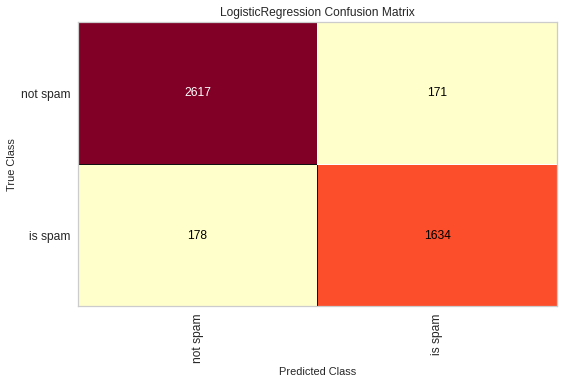

In [32]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(logreg, classes=["not spam", "is spam"])

cm.fit(X, y)
cm.score(X, y)
cm.show();

In [33]:
# メトリクス（評価尺度）
# spamでないメイルをspamと判断するのは（false negative），大事なメイルがスパムフォルダに入ってしまうので困る．
# spamをspamでないと判断するのは（false positive），スパムを消せば良いのであまり困らない．

# 他の尺度が必要

# true positive rate = recall = TP/(TP+FN)
# false positive rate = 1-precision = FP/(TN+FP)
# F1 score = 2 * ((precision * recall) / (precision + recall))

TP, FN, FP, TN = 2665, 123, 190, 1622
precision =  TP/(TP+FP)
recall = TP/(FN+TP)
print( "precision=", precision) 
print( "recall=", recall  ) 
print( "F1 score=", 2*(precision*recall)/(precision+recall) )

precision= 0.9334500875656743
recall= 0.9558823529411765
F1 score= 0.9445330497962078


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  "X does not have valid feature names, but"


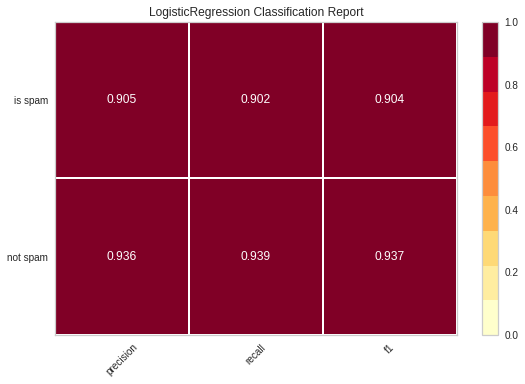

In [34]:
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(logreg,classes=["not spam","is spam"])

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();

In [35]:
# 閾値 (threshold)を変えてみる
# ロジスティック回帰は，spamでない確率を推定し，それが閾値より大きいとspamでない，それ以外のときspamと判定する．

# 通常のロジスティック回帰の閾値は0.5
# 閾値を大きくすると，全部spam（negative)と判定（false positiveが減り，precisionが上がる）
# 閾値を小さくすると，全部spamでない(positive)と判定（false negativeが減り，recall が上がる）

# f1 scoreはバランスをとる．

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  "X does not have valid feature names, but"


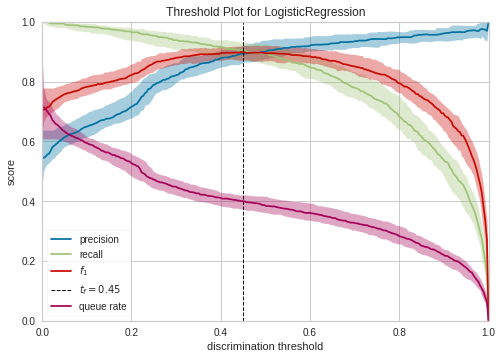

In [36]:
from yellowbrick.classifier import DiscriminationThreshold

visualizer = DiscriminationThreshold(logreg)

visualizer.fit(X, y)     
visualizer.score(X,y)
visualizer.show();    

In [37]:
# ROC曲線
# ROC: 受信者操作特性（receiver operating characteristic)
# https://ja.wikipedia.org/wiki/受信者操作特性

# 閾値を1から0に変えると，recall (true positive rate) が増加し，precision (1-false positive rate) が減少する．

# x軸に false positive rate，y軸にtrue positive rateをとると，両方とも1に近づく曲線になる．

# 曲線の下の面積 (AUC: area under the curve) が評価尺度（大きいほど良い）になる．

# true positive rate = recall = TP/(TP+FN)
# false positive rate = 1-precision = FP/(TN+FP)

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  "X does not have valid feature names, but"


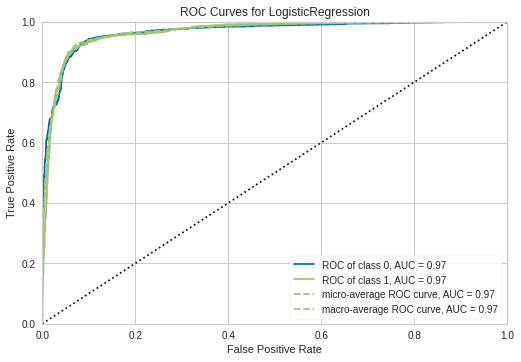

In [38]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(logreg, size=(600,400))

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();

#iris（アヤメ）のデータ

In [39]:
# 2値分類だけでなく，3種類以上のものの分類もできる．
# 以下ではアヤメのデータを用いてロジスティック回帰（分類）を行い，3種類のアヤメを分類する．

import plotly.express as px
iris = px.data.iris()
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [40]:
X = iris[ ['sepal_length','sepal_width','petal_length','petal_width'] ]
#従属変数 y 
y = iris['species_id']
y.head() 

0    1
1    1
2    1
3    1
4    1
Name: species_id, dtype: int64

In [41]:
# 手順１：分類するためのクラスをインポートして，インスタンスを生成する．
# 手順２：fitメソッドを用いて，訓練する．
# 手順３：predictメソッドを用いて予測を行う．

from sklearn.linear_model import LogisticRegression #ロジスティック回帰クラスの読み込み
logreg =  LogisticRegression() # インスタンスの生成
logreg.fit(X, y) # 訓練

LogisticRegression()

In [42]:
logreg.predict([[3, 5, 4, 2]]) # 試しに予測

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([1])

In [43]:
# 予測と実際の誤差を検証
# 元データXを入れたときの予測y_predと本当の値yの比較
# metricsにある正解率を計算する関数 accuracy_score を利用

y_pred = logreg.predict(X)
from sklearn import metrics
print(metrics.accuracy_score(y, y_pred))

0.9733333333333334


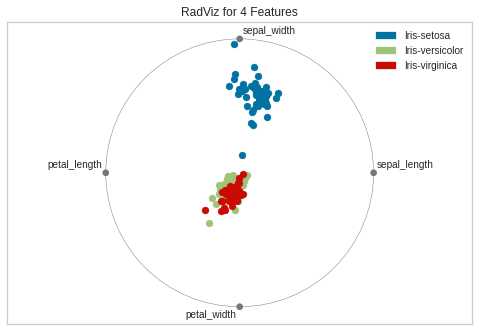

In [44]:
# 可視化
# 以下の2つの可視化を追加
# 1,どの特徴が重要かを可視化するRadViz
# 2,重要と思われる2つの特徴に対して，ロジスティック回帰の分類がどのように行われたかを示すDecisionViz（決定の境界を示す）

# スパムと同じ可視化
# 1,混合行列 (ConfusionMatrix)
# 2,分類レポート (ClassificationReport)
# 3,ROC曲線 (ROCAUC)

# 3値以上の場合には，閾値を変化させる可視化はできないことに注意

from yellowbrick.features import RadViz

visualizer = RadViz(classes=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
                   size=(600,400))

visualizer.fit(X, y)           
visualizer.transform(X)       
visualizer.show();

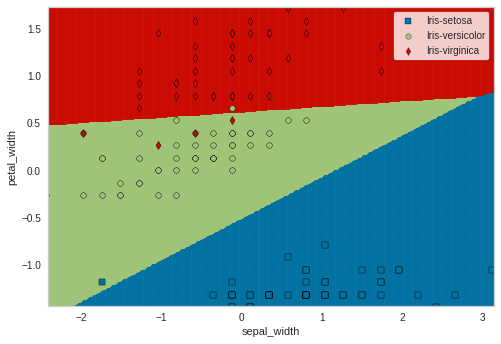

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from yellowbrick.contrib.classifier import DecisionViz

X = iris[ ['sepal_width','petal_width'] ] # 2次元を切り出す
X = StandardScaler().fit_transform(X) #可視化のためにスケーリングしておく

viz = DecisionViz(
    logreg, 
    features = ['sepal_width','petal_width'],
    classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
)
viz.fit(X, y)
viz.draw(X, y)
viz.show();

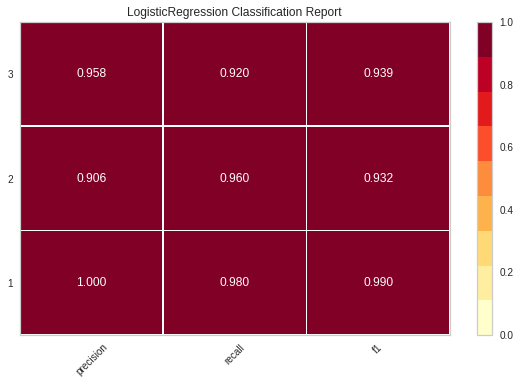

In [46]:
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(logreg)

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();

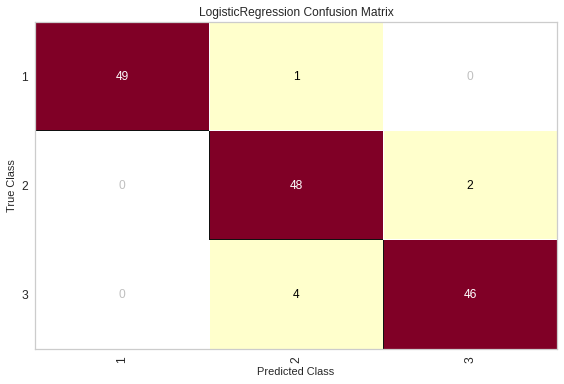

In [47]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(logreg)

cm.fit(X, y)
cm.score(X, y)
cm.show();

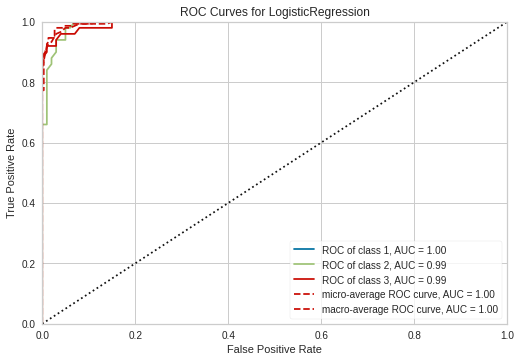

In [48]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(logreg, size=(600,400))

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();

#毒キノコの判定

In [49]:
# ここでは，データから毒キノコか否かを判定する.
# target列がターゲット（従属変数）であり，edibleが食用，poisonousが毒である．
# 他の列のデータもすべて数値ではない．ここでは，scikit-learnのprocessingを用いて，数値に変換してからロジスティック回帰により分類を行う．

mashroom = pd.read_csv("http://logopt.com/data/mashroom.csv")
mashroom.head()

,target,shape,surface,color
0,edible,convex,smooth,yellow
1,edible,bell,smooth,white
2,poisonous,convex,scaly,white
3,edible,convex,smooth,gray
4,edible,convex,scaly,yellow


In [50]:
X = mashroom.drop("target",axis=1)
y = mashroom.target

In [51]:
# 前処理(preprocessing)
# sklearn.preprocessingモジュールにあるLabelEncoderクラスのfit_transformメソッドを用いてターゲット列を数値化する．
# edibleは0に，poisonousは1に変換されていることが分かる．

# 独立変数 XX に対しては，OrdinalEncoderを用いる．これによって文字列データが数値に変換されていることが分かる．
# なお，OneHotEncoderを使うと，ダイヤモンドの例題でダミー変数に変換したのと同じことができる．

from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)
y

array([0, 0, 1, ..., 0, 1, 0])

In [52]:
from sklearn.preprocessing import OrdinalEncoder
X = OrdinalEncoder().fit_transform(X)
X

array([[2., 3., 9.],
       [0., 3., 8.],
       [2., 2., 8.],
       ...,
       [3., 3., 0.],
       [4., 2., 0.],
       [2., 3., 0.]])

In [53]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(multi_class='auto',solver="liblinear")
logreg.fit(X,y)

LogisticRegression(solver='liblinear')

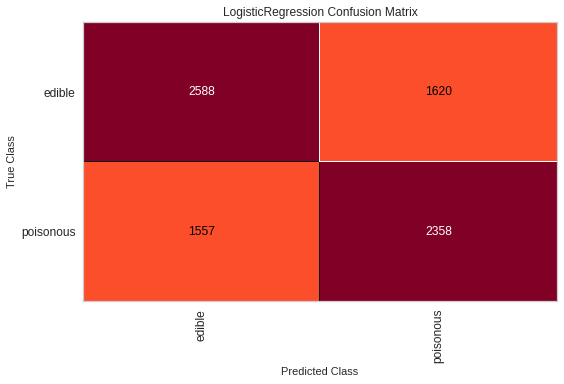

In [54]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(logreg,classes=["edible","poisonous"])

cm.fit(X, y)
cm.score(X, y)
cm.show();

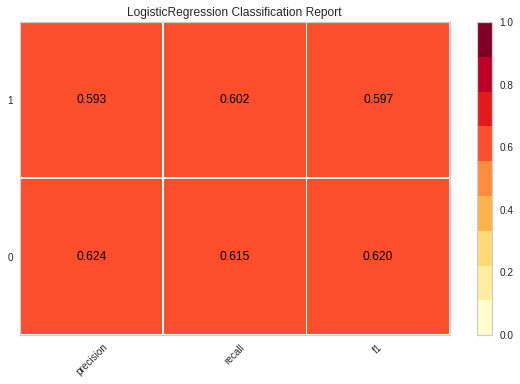

In [55]:
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(logreg)

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();


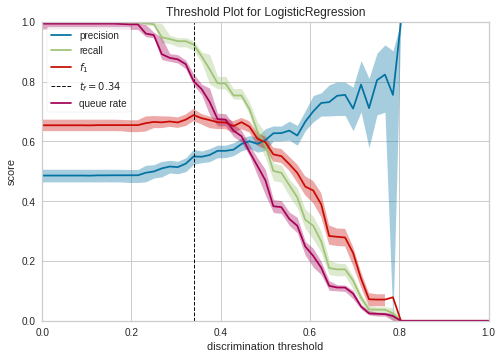

In [56]:
from yellowbrick.classifier import DiscriminationThreshold

visualizer = DiscriminationThreshold(logreg)

visualizer.fit(X, y)     
visualizer.score(X,y)
visualizer.show();   

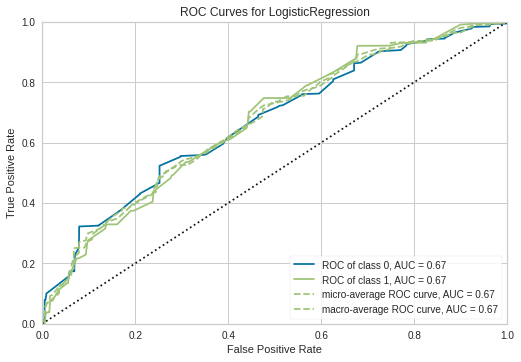

In [57]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(logreg, size=(600,400))

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show();


In [58]:
# 問題（クレジットカード）
# 以下のクレジットカードのデフォルトの判定データに対してロジスティック回帰を行い， 混合行列を描画せよ．
# default列にデフォルトか否かの情報があり，他の列の情報を用いて分類せよ．

credit = pd.read_csv("http://logopt.com/data/credit.csv")
credit.head()

,limit,sex,edu,married,age,apr_delay,may_delay,jun_delay,jul_delay,aug_delay,sep_delay,apr_bill,may_bill,jun_bill,jul_bill,aug_bill,sep_bill,apr_pay,may_pay,jun_pay,jul_pay,aug_pay,sep_pay,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [59]:
# 問題（部屋）
# 以下の部屋が使われているか否かを判定するデータに対してロジスティック回帰を行い，混合行列とROC曲線を描画せよ．
# occupancy列が部屋が使われているか否かを表す情報であり，これをdatetime列以外の情報から分類せよ．

occupancy = pd.read_csv("http://logopt.com/data/occupancy.csv")
occupancy.head()

,datetime,temperature,relative humidity,light,CO2,humidity,occupancy
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [60]:
# 問題（タイタニック）
# titanicデータに対してロジスティック回帰を行い，死亡確率の推定を行え． また，混合行列とROC曲線を描画せよ．

# ヒント：このデータは欠損値を含んでいる．pandasのところで学んだ欠損値処理を参照せよ．
# 非数値の（カテゴリー）データをどのように数値化するかには色々な方法がある．自分で色々工夫せよ．

titanic = pd.read_csv("http://logopt.com/data/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [61]:
# 問題（胸部癌）
# http://logopt.com/data/cancer.csv にある胸部癌か否かを判定するデータセットを用いて分類を行え．
# 最初の列diagnosisが癌か否かを表すものであり，'M'が悪性（malignant），'B'が良性（benign）を表す．

cancer = pd.read_csv("http://logopt.com/data/cancer.csv", index_col=0)
cancer.head().T #横長なので転置して表示する．

id,842302,842517,84300903,84348301,84358402
diagnosis,M,M,M,M,M
radius_mean,17.99,20.57,19.69,11.42,20.29
texture_mean,10.38,17.77,21.25,20.38,14.34
perimeter_mean,122.8,132.9,130,77.58,135.1
area_mean,1001,1326,1203,386.1,1297
smoothness_mean,0.1184,0.08474,0.1096,0.1425,0.1003
compactness_mean,0.2776,0.07864,0.1599,0.2839,0.1328
concavity_mean,0.3001,0.0869,0.1974,0.2414,0.198
concave points_mean,0.1471,0.07017,0.1279,0.1052,0.1043
symmetry_mean,0.2419,0.1812,0.2069,0.2597,0.1809


#K 近傍法による分類と可視化

In [62]:
# 4種類のフルーツを重量と色で分類する．

# フルーツは数値だが，順に "apple", "mandarin","orange","lemon" を表す．
# KK 近傍法とは，(Xの空間で）データに近い KK 個のデータの値(y)の多数決で分類を行う最も簡単な分類手法である．
# 以下のようにしてクラスをインポートできる．

from sklearn.neighbors import KNeighborsClassifier

In [63]:
# クラス KNeighborsClassifier は引数 n_neighbors でパラメータ KK を設定できる．
# KK を色々変えて実験せよ．

fruit = pd.read_csv("http://logopt.com/data/fruit_simple.csv")
fruit.head()

,fruit_label,mass,color_score
0,1,192,0.55
1,1,180,0.59
2,1,176,0.60
3,2,86,0.80
4,2,84,0.79


正解率= 1.0


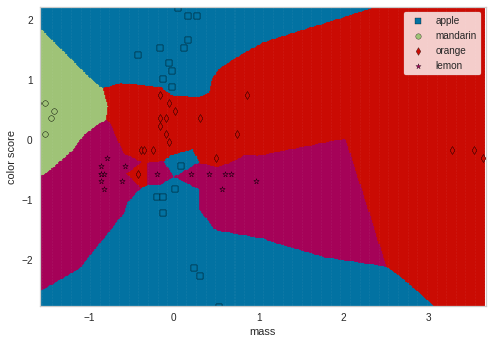

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from yellowbrick.contrib.classifier import DecisionViz

X=fruit.drop("fruit_label",axis=1)
y=fruit.fruit_label
X = StandardScaler().fit_transform(X) #可視化のためにスケーリングしておく

knn = KNeighborsClassifier(1) #Kを1にして実験
knn.fit(X, y) # 訓練
y_pred = knn.predict(X)

print("正解率=",metrics.accuracy_score(y, y_pred))

viz = DecisionViz(
    knn, title="Nearest Neighbors",
    features=['mass', 'color score'], classes=["apple", "mandarin","orange","lemon"]
)
viz.fit(X, y)
viz.draw(X, y)
viz.show();

In [65]:
# 問題（アヤメ）
# irisデータに対して，KK 近傍法で元データを予測したしたときの正解率を計算せよ．パラメータ KK（近傍の数）が5のときはどうか？
# また，パラメータ KK が 1のときはどうか？

# 注意：DecisionVizによる可視化は2次元データではないので、そのままではできない． 適当な特徴ベクトルを切り出してから可視化を行え．

#多項式回帰

In [66]:
# 回帰や分類を行う際に予測誤差が小さい方が望ましいことは言うまでもない． 
# しかし，予測誤差を小さくするために変数（特性）を増やしすぎると， トレーニングデータに適合しすぎて，実際のデータに対して良い結果を出さない 過剰適合(overfitting; 過学習)が発生してしまう．

# この関数は重み ww に対する線形関数であるので，（特性の数は 33倍になるが） 線形回帰と同じように最適な重みを計算することができる． 
# ちなみに，このような回帰を多項式回帰(polynomial regression)とよぶ． 一般に高次の多項式回帰でトレーニングデータの数が少ない場合には，過剰適合が発生する．
# 宣伝の効果のデータを用いて多項式回帰を行う．

# pandasで2次の項（たとえばテレビとラジオの相乗効果の列 TV*Radio）を生成してから，線形回帰を行う．

data = pd.read_csv('http://logopt.com/data/Advertising.csv', index_col =0)
data['TV*Radio'] = data.TV * data.Radio
data['TV*Newspaper'] = data.TV * data.Newspaper
data['Radio*Newspaper'] = data.Radio * data.Newspaper
data.head()

,TV,Radio,Newspaper,Sales,TV*Radio,TV*Newspaper,Radio*Newspaper
1,230.1,37.8,69.2,22.1,8697.78,15922.92,2615.76
2,44.5,39.3,45.1,10.4,1748.85,2006.95,1772.43
3,17.2,45.9,69.3,9.3,789.48,1191.96,3180.87
4,151.5,41.3,58.5,18.5,6256.95,8862.75,2416.05
5,180.8,10.8,58.4,12.9,1952.64,10558.72,630.72


In [67]:
X = data[['TV', 'Radio', 'Newspaper','TV*Radio','TV*Newspaper','Radio*Newspaper']]
y = data['Sales']

In [68]:
from sklearn.linear_model import LinearRegression #クラスのインポート
lin_reg = LinearRegression()     # 線形回帰クラスのインスタンス生成
lin_reg.fit(X, y)    # 訓練
yhat = lin_reg.predict(X)   # 予測
print(lin_reg.score(X,y)) #決定係数　（線形回帰だと R^2は 0.897210638179

0.968631106625557


In [69]:
print("y-切片= ",lin_reg.intercept_)
print("係数 = ",lin_reg.coef_)

y-切片=  6.460158489941875
係数 =  [ 2.03270962e-02  2.29291894e-02  1.70339370e-02  1.13928001e-03
 -7.97143541e-05 -1.09597607e-04]


#過剰適合

In [70]:
# 元データ（訓練データ）を入れてテストをすることは推奨されない． K(=1)近傍法を適用したときのように，過剰適合してしまうからである．
# これを避けるための一番簡単な方法は，訓練データをテストデータを分けることである． train_test_split関数を使うと簡単にできる．

# 例としてBostonの住宅データの予測を行う．
# medvが住宅の価格で，他のデータ（犯罪率や人口など）から予測する．

import pandas as pd
boston = pd.read_csv('http://logopt.com/data/Boston.csv',index_col=0)
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [71]:
X = boston.drop("medv",axis=1) # 最後の列以外のデータを独立変数（特徴ベクトル）として抽出
y = boston.medv #最後の列(medv)を従属変数として抽出


In [72]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)#30%のデータをテスト用，それ以外を訓練用に分離


In [73]:
from sklearn.linear_model import LinearRegression #クラスのインポート
reg = LinearRegression()     # 線形回帰クラスのインスタンス生成
reg.fit(X_train, y_train)    # 訓練
yhat = reg.predict(X_test)   # 予測
print(reg.score(X_test,y_test)) #決定係数

0.7527796215280691


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



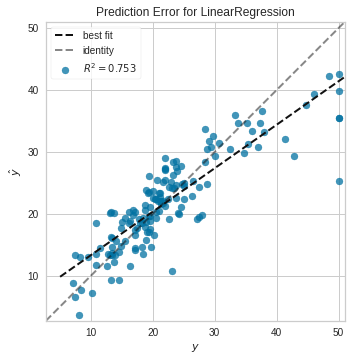

In [74]:
# 可視化
# 訓練データで訓練し，テストデータで評価する．

from yellowbrick.regressor import PredictionError

visualizer = PredictionError(reg)

visualizer.fit(X_train, y_train)  
visualizer.score(X_test, y_test)  
visualizer.show();

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



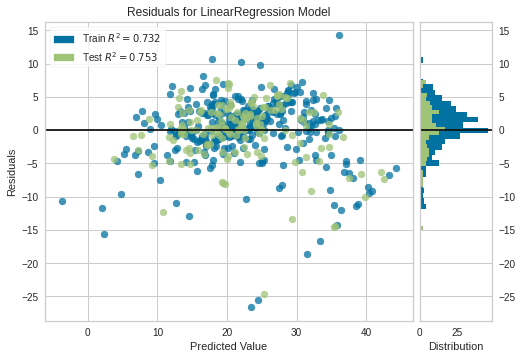

In [75]:
from yellowbrick.regressor import ResidualsPlot

visualizer = ResidualsPlot(reg)

visualizer.fit(X_train, y_train)  
visualizer.score(X_test, y_test)  
visualizer.show();

#リッジ回帰

In [76]:
# 過剰適合を避けるための方法として正則化 (regulalization) がある。
# 正則化を追加した線形回帰は，リッジ回帰(ridge regression)とよばれる．
# 正則化のアイディアは単純であり，重み ww を小さくするような項を費用関数に追加するだけである．

# 追加された2項目が重みを小さくし，これによって過剰適合が軽減される． パラメータ \lambdaλ は正則化パラメータ(regularization parameter)とよばれ， 誤差と過剰適合のトレードオフをとるために用いられる． 
# \lambdaλ が小さいときには，誤差は少なくなるが過剰適合の危険性が増大する． 逆に \lambdaλ を大きくすると，誤差は大きくなり，過剰適合は回避される傾向になる．
# パラメータ \lambdaλ はリッジ回帰クラス Ridge では引数 alpha で与える．

from sklearn.linear_model import Ridge #クラスのインポート
reg = Ridge(alpha=10.0)     # リッジ回帰クラスのインスタンス生成
reg.fit(X_train, y_train)    # 訓練
yhat = reg.predict(X_test)   # 予測
print(reg.score(X_test,y_test)) #決定係数

0.7379534505159683


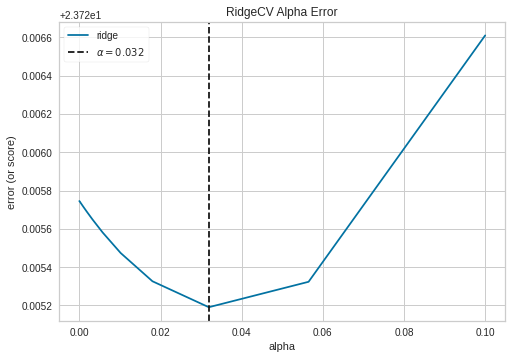

In [77]:
# 最も良い正則化パラメータalphaを求める．
# 後述する交差検証を使い，yellowbrickのAlphaSelectionで可視化する．

from sklearn.linear_model import  RidgeCV
from yellowbrick.regressor import AlphaSelection
import numpy as np

alphas = np.logspace(-100, -1, 400)
model = RidgeCV(alphas=alphas)
visualizer = AlphaSelection(model)
visualizer.fit(X, y)
visualizer.show();

In [78]:
reg = Ridge(alpha=0.032)     # リッジ回帰クラスのインスタンス生成
reg.fit(X_train, y_train)    # 訓練
yhat = reg.predict(X_test)   # 予測
print(reg.score(X_test,y_test)) #決定係数

0.752680609643728


In [79]:
# 問題（アヤメ，タイタニック，ダイヤモンド）
# 1,irisデータを訓練用とテスト用に分けてから，ロジスティック回帰による分類を行い，正解率を計算せよ．


In [80]:
# 2,titanicデータ訓練用とテスト用に分けてから，ロジスティック回帰による分類を行い，正解率を計算せよ．

In [81]:
# 3,例題2で用いた ダイアモンドの価格データhttp://logopt.com/data/Diamond.csv に対して線形回帰とリッジ回帰による予測を行え．また，訓練用とテスト用に分けて決定係数 R^2R 
# 2を計算し，評価せよ． ただしリッジ回帰の正則化パラメータは 0.03 と設定せよ．

#カーネルとSVM (Support Vector Machine)

In [82]:
import plotly.express as px
iris = px.data.iris()
#  独立変数（特徴ベクトル） X 
X = iris[ ['sepal_length','sepal_width','petal_length','petal_width'] ]
#従属変数 y 
y = iris['species_id']
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [83]:
from sklearn.svm import SVC      #クラスのインポート
svc = SVC(kernel='rbf', gamma="scale")        # インスタンス生成
svc.fit(X_train, y_train)    # 訓練
yhat = svc.predict(X_test)   # 予測
from sklearn import metrics
print(metrics.accuracy_score(y_test, yhat)) 

0.9777777777777777


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but SVC was fitted with feature names



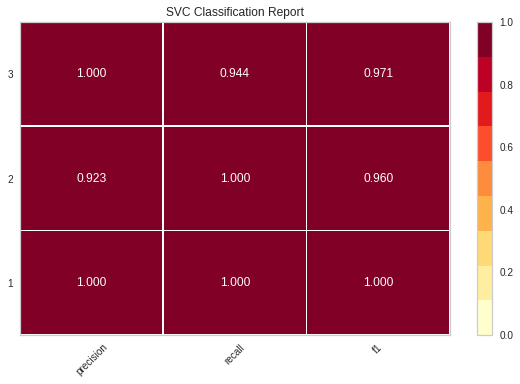

In [84]:
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(svc)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show();


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but SVC was fitted with feature names



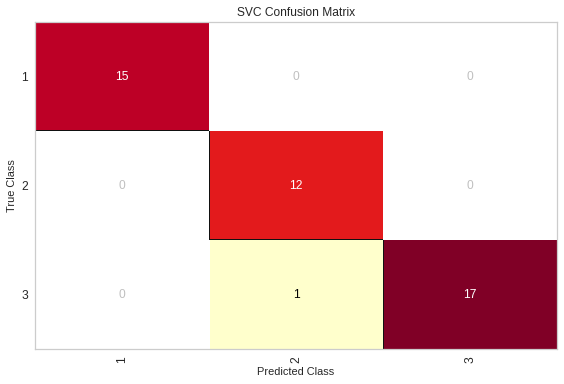

In [85]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(svc)

cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show();

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning:

X does not have valid feature names, but SVC was fitted with feature names



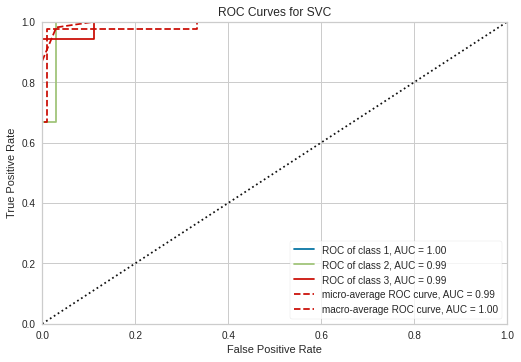

In [86]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(svc, size=(600,400))

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show();

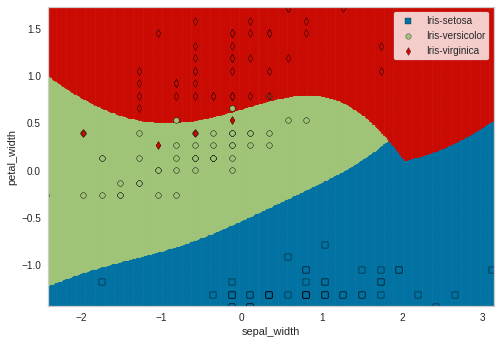

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from yellowbrick.contrib.classifier import DecisionViz

X = iris[ ['sepal_width','petal_width'] ] # 2次元を切り出す
X = StandardScaler().fit_transform(X) #可視化のためにスケーリングしておく

viz = DecisionViz(
    svc,
    features = ['sepal_width','petal_width'],
    classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
)
viz.fit(X, y)
viz.draw(X, y)
viz.show();

#仮説の評価

In [88]:
# トレーニングデータだけを用いて学習すると，他のデータに対して役に立たない危険性がある． このような過剰適合を避けるために， 特性の数を減らしたり，パラメータを調整したりする方法を学んだが， ここではどのモデルを採用すれば良いかを評価するための方法論について述べる．
# 学習した仮説関数が正しいかどうかを検証するための基本は， データを分けることである． 最も簡単なのは，トレーニングデータとテストデータの2つに分け， 学習（費用関数を最小化する重み ww の決定）はトレーニングデータで行い， 評価（正解データとの誤差を計算）はテストデータで行う方法である．

# データの数が足りない場合には，トレーニングデータとテストデータを入れ替えて行う方法が行われる． これを交差検証(cross validation)とよぶ．

# 上で用いたサポートベクトル分類 svcのインスタンスで試してみる．
# 引数のcvは交差検証(cross validiation)の分割数．
# 引数のscoring='accuracy'は分類の正解率を表す指標を指定している．
# （回帰分析のときには，引数を決定変数'r2'などに設定する．）

from sklearn.model_selection import cross_val_score 
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

[1.         1.         1.         0.93333333 0.93333333 0.86666667
 0.8        1.         0.93333333 1.        ]
0.9466666666666667


#ニューラルネット

In [89]:
from sklearn.neural_network import MLPClassifier #ニューラルネット
neural = MLPClassifier()
neural.fit(X_train, y_train)    # 訓練
yhat = neural.predict(X_test)   # 予測
print(metrics.accuracy_score(y_test, yhat)) 
scores = cross_val_score(neural, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

1.0
[1.         1.         1.         0.93333333 0.93333333 0.86666667
 0.86666667 1.         0.93333333 1.        ]
0.9533333333333334


#単純Bayes

In [90]:
# 単純Bayes法はデータがしたがう確率分布についての情報をもつ場合に有効であり， 分類だけでなく不適合値の検出などの応用にも用いることができる．

from sklearn.naive_bayes import GaussianNB #単純Bayes
bayes = GaussianNB()
bayes.fit(X_train, y_train)    # 訓練
yhat = bayes.predict(X_test)   # 予測
print(metrics.accuracy_score(y_test, yhat)) 
scores = cross_val_score(bayes, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

0.9555555555555556
[1.         0.86666667 1.         0.93333333 0.93333333 0.86666667
 0.86666667 0.93333333 1.         1.        ]
0.9400000000000001


#決定木

In [91]:
# 決定木(decision tree)は，回帰にも分類にも使えるが，ここでは分類を用いて解説する． 決定木では，1つの特性に対する分岐によってトレーニング集合を分類していく． 
# 分岐の情報は，根付き木で表現される． 決定木における仮説関数は，木の葉に対する出力の値の多数決をとったものである． どの特性を優先して分岐するかは，情報量（エントロピー）の増加が最大になるものを選択していく方法が一般的である． この手法は，結果の解釈が可能な点が利点であるが，過剰適合に陥りやすいのが弱点である．

from sklearn import tree
tree_class = tree.DecisionTreeClassifier() #決定木
tree_class.fit(X_train, y_train)    # 訓練
yhat = tree_class.predict(X_test)   # 予測
print(metrics.accuracy_score(y_test, yhat))
scores = cross_val_score(tree_class, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

0.9333333333333333
[0.93333333 0.93333333 1.         0.93333333 0.86666667 0.8
 0.8        1.         1.         1.        ]
0.9266666666666665


#アンサンブル法

In [92]:
# アンサンブル法(ensemble method)とは，複数のアルゴリズムを合わせることによって， より高精度の予測もしくは分類を得るためのメタアルゴリズムである． 
# その基本原理は「ばらつきをもったデータを集約するとばらつきが減少する」という 統計の公理であり，様々なデータや手法で得られた結果を， 平均したり多数決したりすることによって，よりばらつきの少ない結果を得ようというものである．

# バギング(bagging; bootstrap aggregatingの略）は，ブートストラップ(bootstrap)とよばれるリサンプリング法によって複数のトレーニング集合を作成し， それらのデータを用いて作成したモデルを平均（回帰の場合）もしくは多数決（分類の場合）によって統合する方法である．
# ブースティング(boosting)は，複数の手法の重み付けを学習によって調整する方法である．
# ランダム森(random forest)は，決定木ベースのバギングである

In [93]:
from sklearn.ensemble import RandomForestClassifier #ランダム森
forest = RandomForestClassifier()
forest.fit(X_train, y_train)    # 訓練
yhat = forest.predict(X_test)   # 予測
print(metrics.accuracy_score(y_test, yhat)) 
scores = cross_val_score(forest , X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

0.9555555555555556
[0.93333333 0.93333333 1.         0.93333333 0.86666667 0.8
 0.8        0.93333333 1.         1.        ]
0.9199999999999999


In [94]:
# 問題（タイタニック）
# titanicデータを訓練用とテスト用に分けてから，ニューラルネット，単純Bayes，決定木，ランダム森による分類を行い，交差検証を行え．

#クラスタリング

In [95]:
import pandas as pd
L = [ 'Alcohol', 'Malic','Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoid',
     'Proanthocyanins', 'Color', 'Hue', 'OD280', 'OD315', 'Proline']
wine = pd.read_csv('http://logopt.com/data/wine.data',names=L)
wine.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoid,Proanthocyanins,Color,Hue,OD280,OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [96]:
from sklearn.cluster import KMeans  # クラスをインポート
kmeans = KMeans(n_clusters=4)       # インスタンス生成
kmeans.fit(wine)                    # 訓練


KMeans(n_clusters=4)

In [97]:
wine['label'] = kmeans.labels_
wine.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoid,Proanthocyanins,Color,Hue,OD280,OD315,Proline,label
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,3
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,3
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


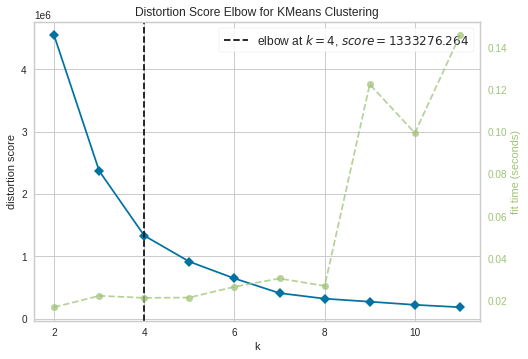

In [98]:
# パラメータKの適正化 （エルボー法）
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(kmeans, k=(2,12))
visualizer.fit(wine)        
visualizer.show();


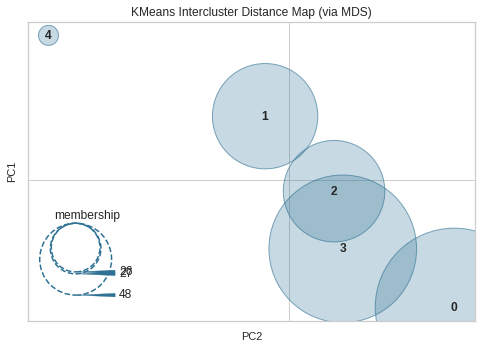

In [99]:
# 可視化
from yellowbrick.cluster import InterclusterDistance

kmeans = KMeans(n_clusters=5) 
visualizer = InterclusterDistance(kmeans)
visualizer.fit(wine)       
visualizer.show(); 

In [100]:
# 問題（アヤメ）
# irisのデータセットの各データを kk-平均法を用いて3つのクラスターに分けよ．


#次元削減

In [101]:
# irisデータセットを用いて主成分分析と可視化の方法を説明する．

import pandas as pd
iris = pd.read_csv("http://logopt.com/data/iris.data",
                   names=['sepal length','sepal width','petal length','petal width', 'class'])
X = iris[ ['sepal length','sepal width','petal length','petal width'] ]

In [102]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2次元に射影
pca.fit(X)
pca.components_ #射影行列

array([[ 0.36158968, -0.08226889,  0.85657211,  0.35884393],
       [ 0.65653988,  0.72971237, -0.1757674 , -0.07470647]])

In [103]:
Z = pca.transform(X) # 射影したデータ
# 射影した2次元データを元のデータフレームに追加
iris['X']=Z[:,0]
iris['Y']=Z[:,1]
iris.head()


,sepal length,sepal width,petal length,petal width,class,X,Y
0,5.1,3.5,1.4,0.2,Iris-setosa,-2.684207,0.326607
1,4.9,3.0,1.4,0.2,Iris-setosa,-2.715391,-0.169557
2,4.7,3.2,1.3,0.2,Iris-setosa,-2.889820,-0.137346
3,4.6,3.1,1.5,0.2,Iris-setosa,-2.746437,-0.311124
4,5.0,3.6,1.4,0.2,Iris-setosa,-2.728593,0.333925


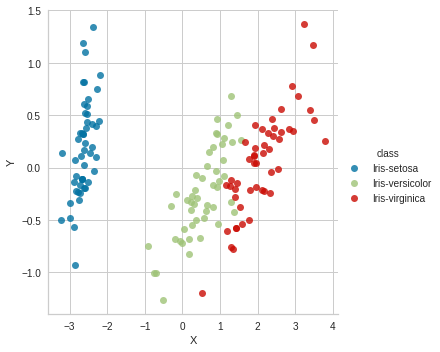

In [104]:
import seaborn as sns
%matplotlib inline
sns.lmplot(x='X',y='Y',hue='class',fit_reg=False,data=iris);


#t-SNE

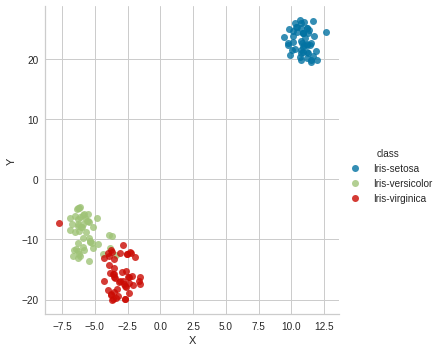

In [105]:
# もう1つの次元削減の手法である t-SNE (t-distributed Stochastic Neighbor Embedding) を紹介する。 直訳すると、tt-分布確率的近傍埋め込みであるが、英語で呼ばれることが多く、ティー・スニーと発音される。
# 簡単に言うと、低次元空間での類似度を元の次元でのデータごとの類似度と（分布の意味で）近くなるような、位置（2次元の場合にはX,Y座標）を求める手法である。
# 通常は、こちらの方が（主成分分析よりは）低次元に射影したデータを可視化したとき綺麗に分類される。

from sklearn.manifold import TSNE
Z = TSNE(n_components=2, random_state=0).fit_transform(X)
# 射影した2次元データを元のデータフレームに追加
iris['X']=Z[:,0]
iris['Y']=Z[:,1]
sns.lmplot(x='X',y='Y',hue='class',fit_reg=False,data=iris);

In [106]:
# 問題（アルコール摂取量）
# http://logopt.com/data/drinks.csv にある国別のアルコール摂取量データを用いて主成分分析を行え．
# 4次元の数値データを2次元に射影し，2次元座標で表示せよ．その際，色調としては，大陸(continent)列を用いよ．

In [107]:
# 問題（ワイン）
# クラスタリングの例で用いたワインのデータを2次元に射影して，クラスタリングされたラベルを色調として描画せよ．

#特徴量の重要度

In [108]:
# ランダム森（RadnomForest）は回帰にも分類にも使える．
# sklearn.inspection にある permutation_importance 関数に， ランダム森インスタンスとX, yを入れると，特徴の重要度を計算してくれる．
# 例として，最初に示した広告による売り上げの予測を行い，各特徴の重要度を計算する．

from sklearn.ensemble import RandomForestRegressor
data = pd.read_csv('http://logopt.com/data/Advertising.csv', index_col =0) #0行目をインデックスにする．
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

rf = RandomForestRegressor()
rf.fit(X, y)

RandomForestRegressor()

In [109]:
from sklearn.inspection import permutation_importance
result = permutation_importance(rf, X, y)
result.importances_mean

array([1.1980921 , 0.67931768, 0.00239905])

In [110]:
# 問題（アヤメ）
# irisデータセットにおける特徴ベクトルの重要度を計算せよ．

import plotly.express as px
iris = px.data.iris()
X = iris[ ['sepal_length','sepal_width','petal_length','petal_width'] ]
y = iris['species_id']